In [ ]:
#  Interexperimental correlation of PRADA reactivity 

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt 

In [ ]:
## 1. Fig 4e --- ---

0.9550861547747839


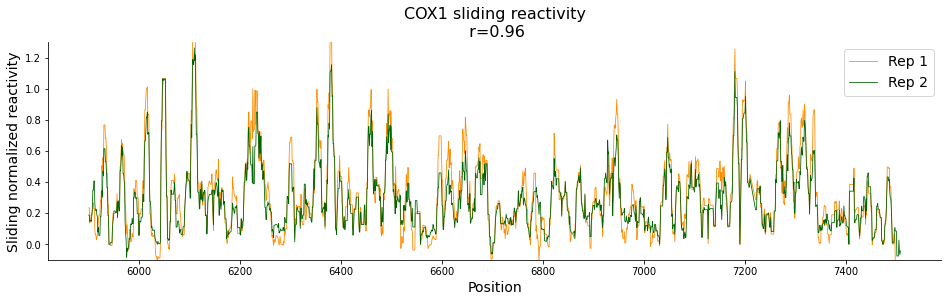

In [6]:
### A. input

rep_1 = pd.read_csv('./Data/PRADA-MaP_living_cells_mitochondria_structure_profiles_biorep1.txt',sep='\t')
rep_1 = rep_1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
rep_1['Norm_profile'] = np.where((rep_1['Sequence'] == 'U') | (rep_1['Sequence'] == 'G'), rep_1['Norm_profile'], 0)

rep_2 = pd.read_csv('./Data/PRADA-MaP_living_cells_mitochondria_structure_profiles_biorep2.txt',sep='\t')
rep_2 = rep_2[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
rep_2['Norm_profile'] = np.where((rep_2['Sequence'] == 'U') | (rep_2['Sequence'] == 'G'), rep_2['Norm_profile'], 0)

combine = pd.merge(rep_1, rep_2,how ='inner', on =['Nucleotide', 'Nucleotide'])
combine.to_csv("./Data/"+'combine_profile_rep1_rep2.csv',sep=',')


### B. ROLLING

roll_rep_1 = combine['Norm_profile_x'].rolling(10).mean()
roll_rep_2 = combine['Norm_profile_y'].rolling(10).mean()

tmp1 = pd.DataFrame(roll_rep_1)
tmp1.columns = ['slide']
tmp1['group'] = 'Biorep1'
tmp1['Nucleotide'] = tmp1.index+1

tmp2 = pd.DataFrame(roll_rep_2)
tmp2.columns = ['slide']
tmp2['group'] = 'Biorep2'
tmp2['Nucleotide'] = tmp2.index+1

df = pd.merge(tmp1,tmp2,how='inner',on=['Nucleotide','Nucleotide'])

alldata = pd.merge(df,combine,how='inner',on=['Nucleotide','Nucleotide'])
alldata = alldata[(alldata['Nucleotide']>=5900) & (alldata['Nucleotide']<=7517)]

alldata = alldata.dropna()
stat = stats.pearsonr(alldata.slide_x, alldata.slide_y)
print(stat[0])

### C. Plots correlation

fig, ax = plt.subplots(figsize=(16, 4), sharex=True, sharey=True)
ax.plot(alldata.Nucleotide, alldata.slide_x, linewidth=0.8, color='darkorange',label='Rep 1')  
ax.plot(alldata.Nucleotide, alldata.slide_y, linewidth=0.8, color='darkgreen',label='Rep 2')
ax.spines[['right', 'top']].set_visible(False) 
plt.legend(loc='best', prop={'size': 14})
ax.set_title('COX1 sliding reactivity'+ '\n r='+str(round(stat[0],2)),fontsize =16)
ax.set_xlabel("Position",size=14)
ax.set_ylabel("Sliding normalized reactivity",size=14)
ax.set_ylim(-0.1,1.3)
ax.set_ylim()

dir_out = './Data/'
plt.savefig(dir_out+'Fig4e_COX1_bioreps_correlation.pdf',bbox_inches='tight', dpi=300) 